# Why these runs produce no gradient: the group has two samples in it

`rollout/raw_reward` on the 9B line is not stuck at zero, which is the thing it
was reported as. Across the three runs on 2026-09-09 it is zero on 28%, 45% and
11% of steps and positive on the rest. The runs still learn nothing, and the
reason is one resolved argument:

```
resolved: rollout_batch=2 n_samples=2 updates_per_rollout=1 -> global_batch=4
```

At a group size of two, GRPO's advantage is **exactly plus or minus one for any
non-zero reward difference**. It carries which of the two samples was better and
nothing about by how much. That is arithmetic, not a defect, and no choice of
normalisation removes it: `scale_free` gives plus or minus one over root two at
the same group size, and its own bound is `sqrt(K-1)`, which is 1 at K=2.

Everything below is generated by
[`reward_zero_variance.ipynb`](./reward_zero_variance.ipynb), which reads
`facts.json` committed beside it rather than re-reading the logs, so this text
and the notebook cannot drift apart.

In [1]:
import json, math
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300,
    "font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8,
    "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

HERE = Path("rl/ldm_reward") if Path("rl/ldm_reward").is_dir() else Path(".")
F = json.loads((HERE / "facts.json").read_text())
SRC, RUNS, DERIV = F["source"], F["runs"], F["derivation"]
ORDER = ["9b-sft-a", "9b-sft-b", "9b-base"]
C = {"9b-sft-a": "#1a6fb5", "9b-sft-b": "#4fa3d1", "9b-base": "#d1710a"}

def save(fig, name):
    """300 dpi, then quantise to 256 colours so the notebook renders inline."""
    p = HERE / "figs" / f"{name}.png"
    fig.savefig(p, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    im = Image.open(p).convert("RGB").quantize(colors=256, method=Image.MEDIANCUT)
    im.save(p, optimize=True)
    print(f"{name}: {p.stat().st_size/1024:.0f} KiB")
    # Show it inline too, so the notebook stands on its own away from the PR body.
    from IPython.display import Image as IPyImage, display
    display(IPyImage(filename=str(p)))

print("facts collected", F["collected_utc"], "| ldm_rl at", F["ldm_rl_head"][:8])

facts collected 2026-09-10T02:19:26Z | ldm_rl at 036f9df4


## 1. The reward is a switch, not a blend

`env.py` declares five mutually exclusive policies and picks one. There is no
validity term, no format term, and no weights, so there is nothing to tune in
the composition. The default is `improvement`.

The part that matters for a zero: **three of the four return paths return the
same `0.0`**, so at the scalar a malformed action, an evaluation that ran and
failed, and a round where nothing was admitted are the same number. The field
that separates them, `components["kind"]`, is computed on every call and written
nowhere.

f5_reward_paths: 35 KiB


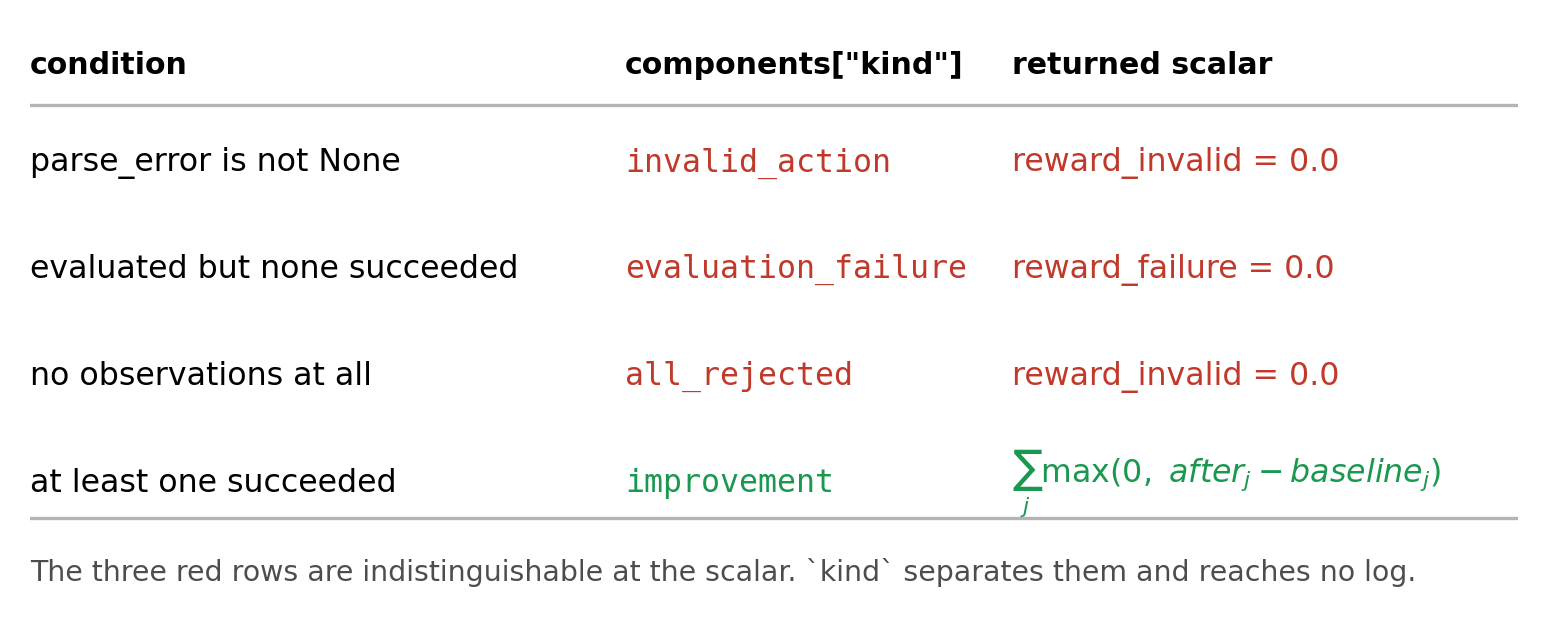

In [2]:
# F5 -- the four ways _reward can return, and what each returns. Three of them
# return the same 0.0, so the scalar cannot say which happened; the field that
# can, `components["kind"]`, is computed and then never written anywhere.
fig, ax = plt.subplots(figsize=(6.4, 2.5)); ax.axis("off")
rows = [
    ("parse_error is not None",  "invalid_action",      "reward_invalid = 0.0", "#c0392b"),
    ("evaluated but none succeeded", "evaluation_failure", "reward_failure = 0.0", "#c0392b"),
    ("no observations at all",   "all_rejected",        "reward_invalid = 0.0", "#c0392b"),
    ("at least one succeeded",   "improvement",         r"$\sum_j \max(0,\ after_j - baseline_j)$", "#1a9850"),
]
for i, (cond, kind, val, col) in enumerate(rows):
    y = 1 - i * 0.24
    ax.text(0.00, y, cond, fontsize=7.6, va="center")
    ax.text(0.40, y, kind, fontsize=7.6, va="center", family="monospace", color=col)
    ax.text(0.66, y, val, fontsize=7.6, va="center", color=col)
ax.text(0.00, 1.20, "condition", fontsize=7.2, weight="bold")
ax.text(0.40, 1.20, 'components["kind"]', fontsize=7.2, weight="bold")
ax.text(0.66, 1.20, "returned scalar", fontsize=7.2, weight="bold")
ax.plot([0, 1], [1.13, 1.13], color="0.7", lw=0.8)
ax.plot([0, 1], [0.20, 0.20], color="0.7", lw=0.8)
ax.text(0.00, 0.06, "The three red rows are indistinguishable at the scalar. "
        "`kind` separates them and reaches no log.", fontsize=6.8, color="0.3")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.30)
save(fig, "f5_reward_paths")

## 2. The reward is a ratchet, so zeros accumulate

`baseline` is the per-objective best over the whole episode's history, not the
previous round. A round scores above zero only by beating the running best, and
the per-objective clip means a round that improves one objective while
destroying another scores as though the loss did not happen.

That predicts the zero fraction should grow through a run. Splitting each run at
its midpoint, two of the three go that way and one goes the other way, so these
three runs do not establish it — the mechanism is read from the definition, not
from this figure, and separating those two is the point of showing it.

What does not depend on the split is the level, and slime measures it directly.
`zero_std/count_no_gradient`, `count_lt_eps` and `count_0.0` are emitted every
rollout into `runs/<RUN>/train.log`; summed against `rollout_batch_size` groups
per step they give 104 of 214 groups carrying no gradient. All three counters
agree run by run (49/49, 37/37, 18/18), which settles a question the group means
could only bound: **every group that carries no gradient is one where every
sample scored zero.** Not one is a group tied at some positive value.

f1_reward_series: 58 KiB


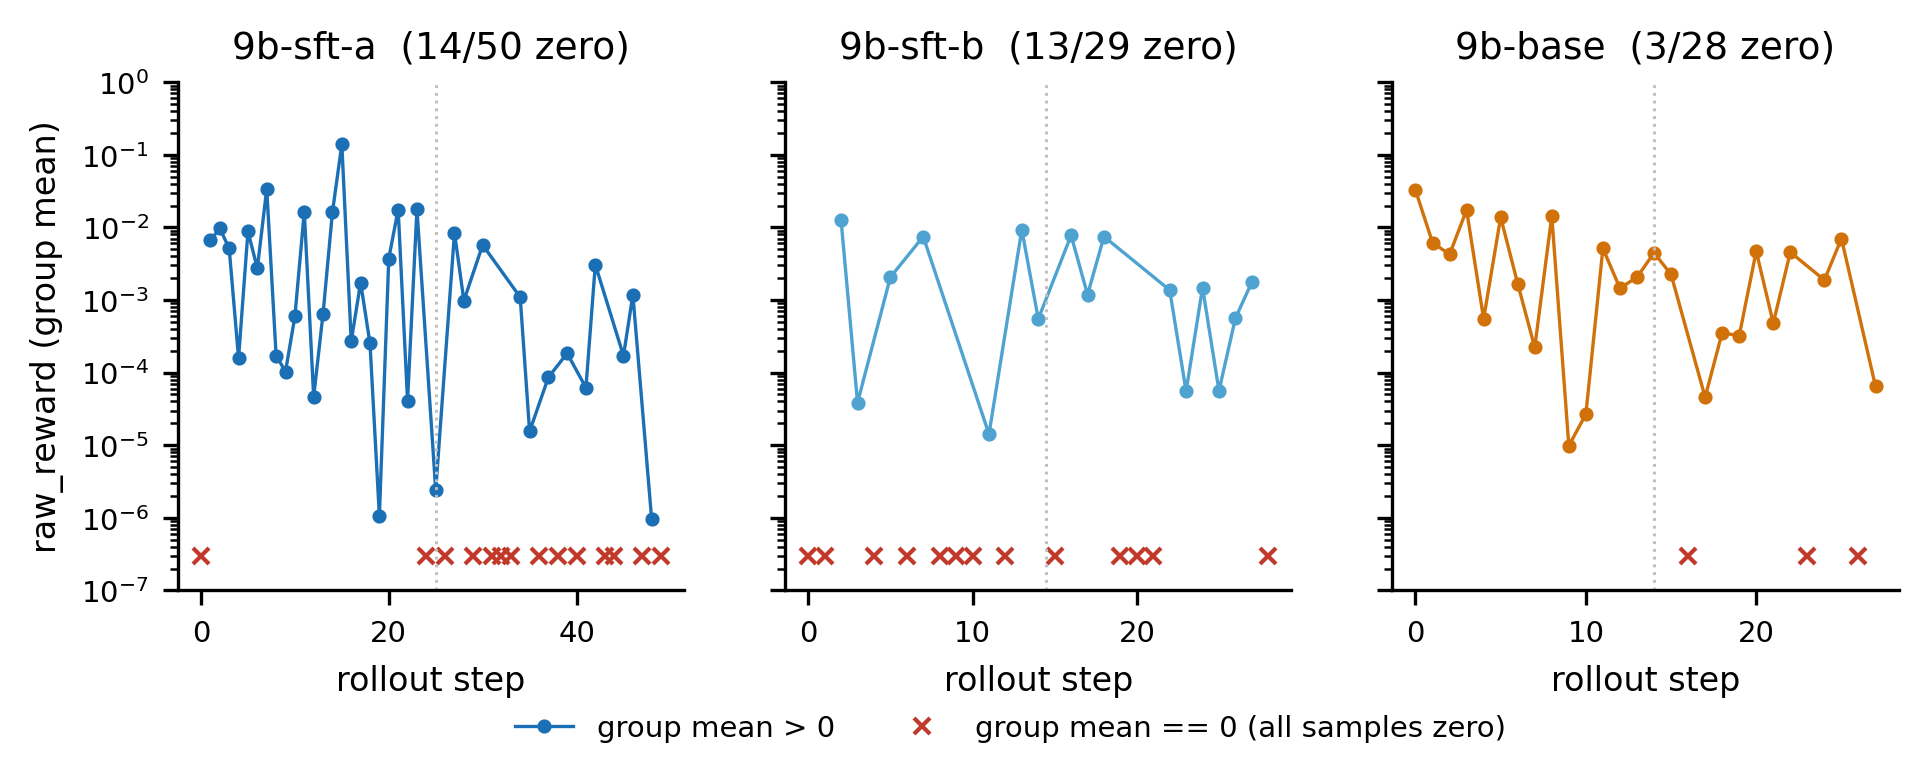

In [3]:
# F1 -- the reward over a run. `rollout/raw_reward` is the group MEAN, and every
# reward path returns a value >= 0, so a mean of exactly 0 means every sample in
# that group scored 0: the group has zero variance and contributes no gradient.
fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.2), sharey=True)
for ax, k in zip(axes, ORDER):
    r = np.array(RUNS[k]["raw_reward"]); x = np.arange(len(r))
    nz = r > 0
    ax.semilogy(x[nz], r[nz], "o-", ms=2.4, lw=0.8, color=C[k], label="group mean > 0")
    ax.plot(x[~nz], np.full((~nz).sum(), 3e-7), "x", ms=4, color="#c0392b",
            label="group mean == 0 (all samples zero)")
    ax.axvline(len(r) / 2, color="0.75", lw=0.7, ls=":")
    ax.set_title(f"{k}  ({RUNS[k]['n_zero']}/{RUNS[k]['steps']} zero)")
    ax.set_xlabel("rollout step")
axes[0].set_ylabel("raw_reward (group mean)")
axes[0].set_ylim(1e-7, 1)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.16), frameon=False)
save(fig, "f1_reward_series")

f2_ratchet: 20 KiB


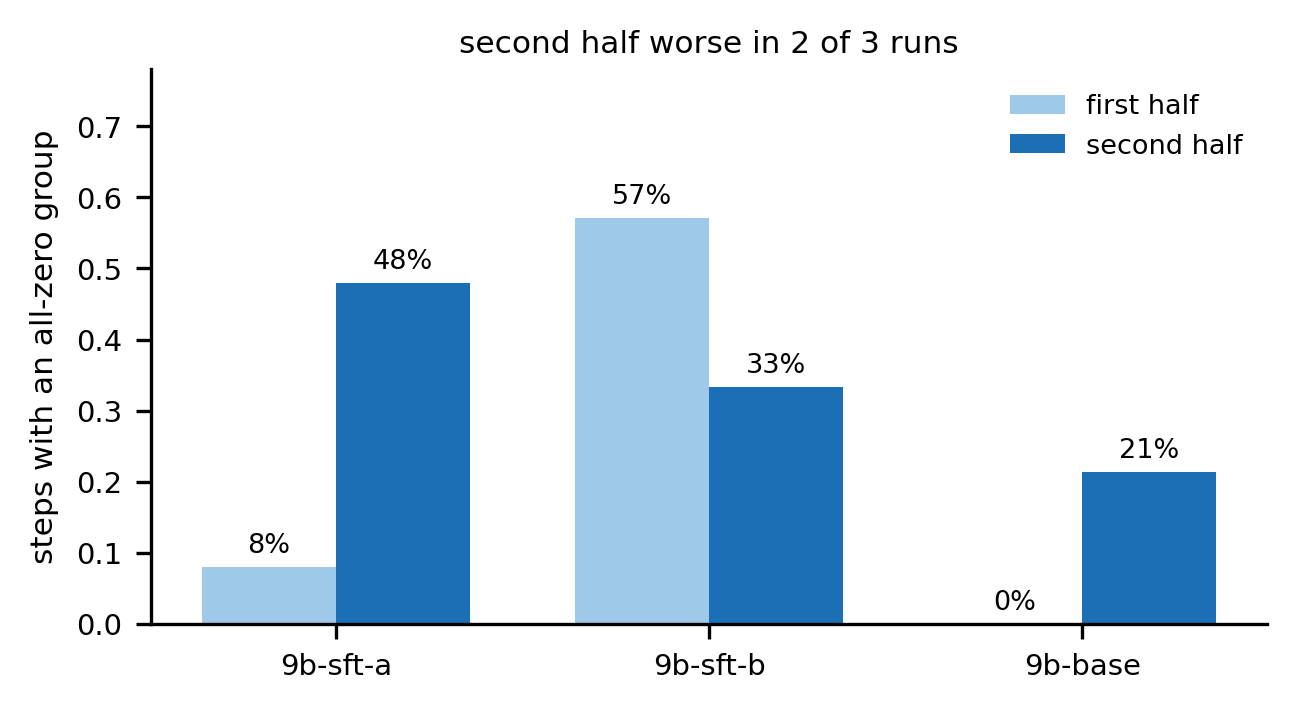

In [4]:
# F2 -- the zero fraction split at the midpoint of each run. The ratchet predicts
# the second half is worse. Two runs go that way and one goes the other way, so
# this does NOT establish the ratchet; it is shown because it is the obvious
# check and it comes out ambiguous. The ratchet itself is read from the code.
fig, ax = plt.subplots(figsize=(4.8, 2.4))
w = 0.36; xs = np.arange(len(ORDER))
first = [RUNS[k]["zero_frac_first_half"] for k in ORDER]
second = [RUNS[k]["zero_frac_second_half"] for k in ORDER]
ax.bar(xs - w/2, first, w, color="#9ec9e8", label="first half")
ax.bar(xs + w/2, second, w, color="#1a6fb5", label="second half")
for x, a, b in zip(xs, first, second):
    ax.text(x - w/2, a + .02, f"{a:.0%}", ha="center", fontsize=6.5)
    ax.text(x + w/2, b + .02, f"{b:.0%}", ha="center", fontsize=6.5)
ax.set_xticks(xs); ax.set_xticklabels(ORDER)
ax.set_ylabel("steps with an all-zero group", fontsize=7.5)
ax.set_ylim(0, 0.78); ax.legend(frameon=False, fontsize=6.5, loc="upper right")
up = sum(1 for k in ORDER if RUNS[k]["zero_frac_second_half"] > RUNS[k]["zero_frac_first_half"])
ax.set_title(f"second half worse in {up} of {len(ORDER)} runs", fontsize=7.5, pad=4)
save(fig, "f2_ratchet")

f2b_no_gradient_groups: 25 KiB


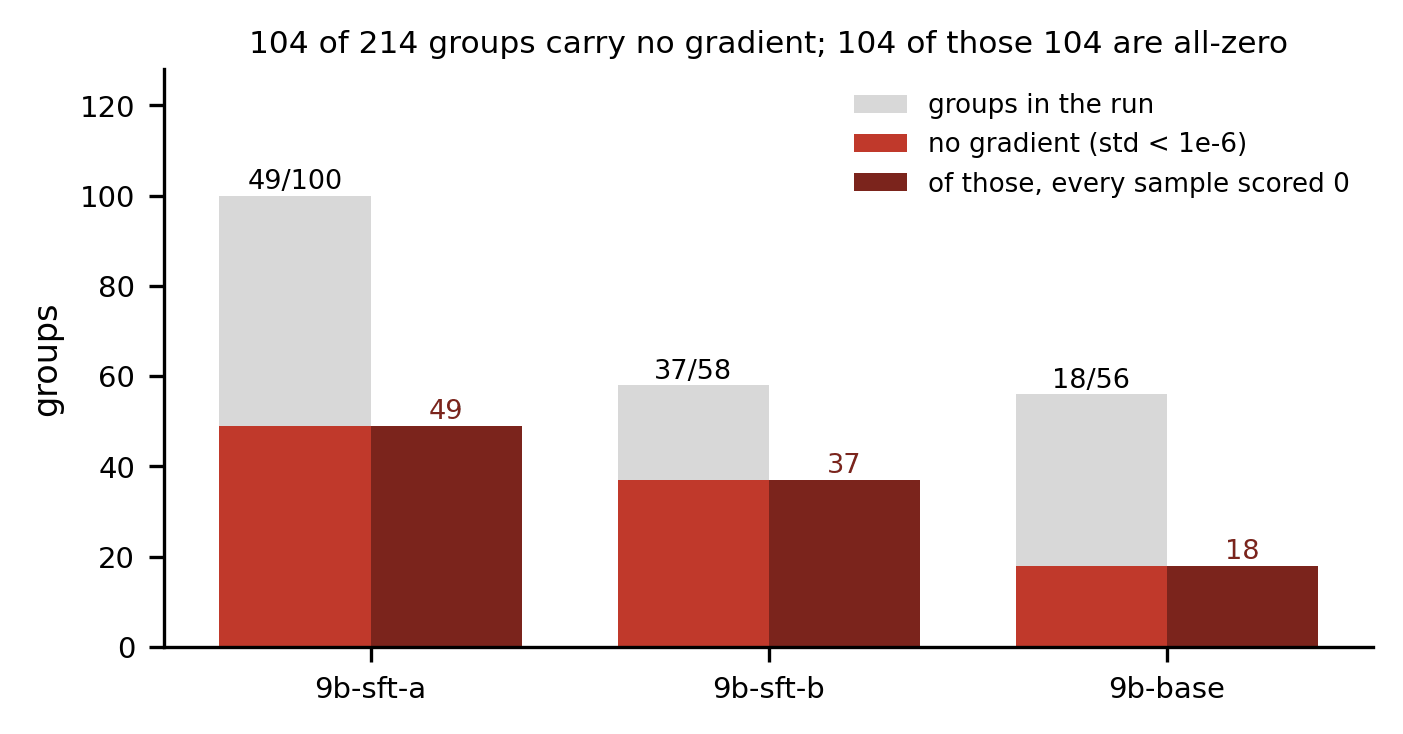

no-gradient 104/214 = 49%;  all-zero 104;  tied-at-positive 0


In [5]:
# F -- the counters slime already emits, read from runs/<RUN>/train.log. These
# say directly what the group-mean series could only bound: how many groups
# carried no gradient, and which of the two ways they got there.
fig, ax = plt.subplots(figsize=(5.2, 2.5))
xs = np.arange(len(ORDER)); w = 0.38
tot = [RUNS[k]["groups_total"] for k in ORDER]
ngr = [RUNS[k]["groups_no_gradient"] for k in ORDER]
zro = [RUNS[k]["groups_exactly_zero"] for k in ORDER]
ax.bar(xs - w/2, tot, w, color="#d8d8d8", label="groups in the run")
ax.bar(xs - w/2, ngr, w, color="#c0392b", label="no gradient (std < 1e-6)")
ax.bar(xs + w/2, zro, w, color="#7b241c", label="of those, every sample scored 0")
for x, t, g, z in zip(xs, tot, ngr, zro):
    ax.text(x - w/2, t + 1.5, f"{g}/{t}", ha="center", fontsize=6.5)
    ax.text(x + w/2, z + 1.5, f"{z}", ha="center", fontsize=6.5, color="#7b241c")
ax.set_xticks(xs); ax.set_xticklabels(ORDER); ax.set_ylabel("groups")
ax.legend(frameon=False, fontsize=6.3, loc="upper right")
ax.set_ylim(0, max(tot) * 1.28)
T = sum(tot); G = sum(ngr); Z = sum(zro)
ax.set_title(f"{G} of {T} groups carry no gradient; {Z} of those {G} are all-zero",
             fontsize=7.5, pad=4)
save(fig, "f2b_no_gradient_groups")
print(f"no-gradient {G}/{T} = {G/T:.0%};  all-zero {Z};  tied-at-positive {G-Z}")

## 3. At K=2 the advantage has no magnitude

For a group of two, the centered rewards are plus and minus half the difference
and the population std is half the difference, so the quotient is plus or minus
one whatever the difference was. The two normalisation modes differ only in what
happens as the difference shrinks toward the epsilon floor.

`legacy_eps` divides by `std + 1e-6`, which attenuates by `std/(std+1e-6)`: half
at a std of 1e-6, a hundredth at 1e-8. These runs ran on `legacy_eps` with
`normalize_advantages = False`, so nothing downstream rescales the attenuation
back out.

How often that floor actually bites here is worth stating rather than implying,
because it is not the main story. `count_lt_eps` equals `count_no_gradient` in
all three runs and both equal `count_0.0`, so every sub-epsilon group here is a
group of exact zeros rather than a group the floor attenuated. Of the 77 steps
with a non-zero group mean, 4 are below 1e-5 and 1 below 1e-6. The floor is a
real defect that should be turned off, and it is not what is costing these runs
their gradient. The group size is.

One claim that does **not** hold and should not be repeated: the logged
`rollout/advantages` cannot be read as evidence here. Every `rollout/*` value is
reduced with `val.float().mean().item()` before logging, and the mean of a
group's advantages is zero by construction. The group std itself is not in these
logs at all.

f3_k2_advantage: 28 KiB


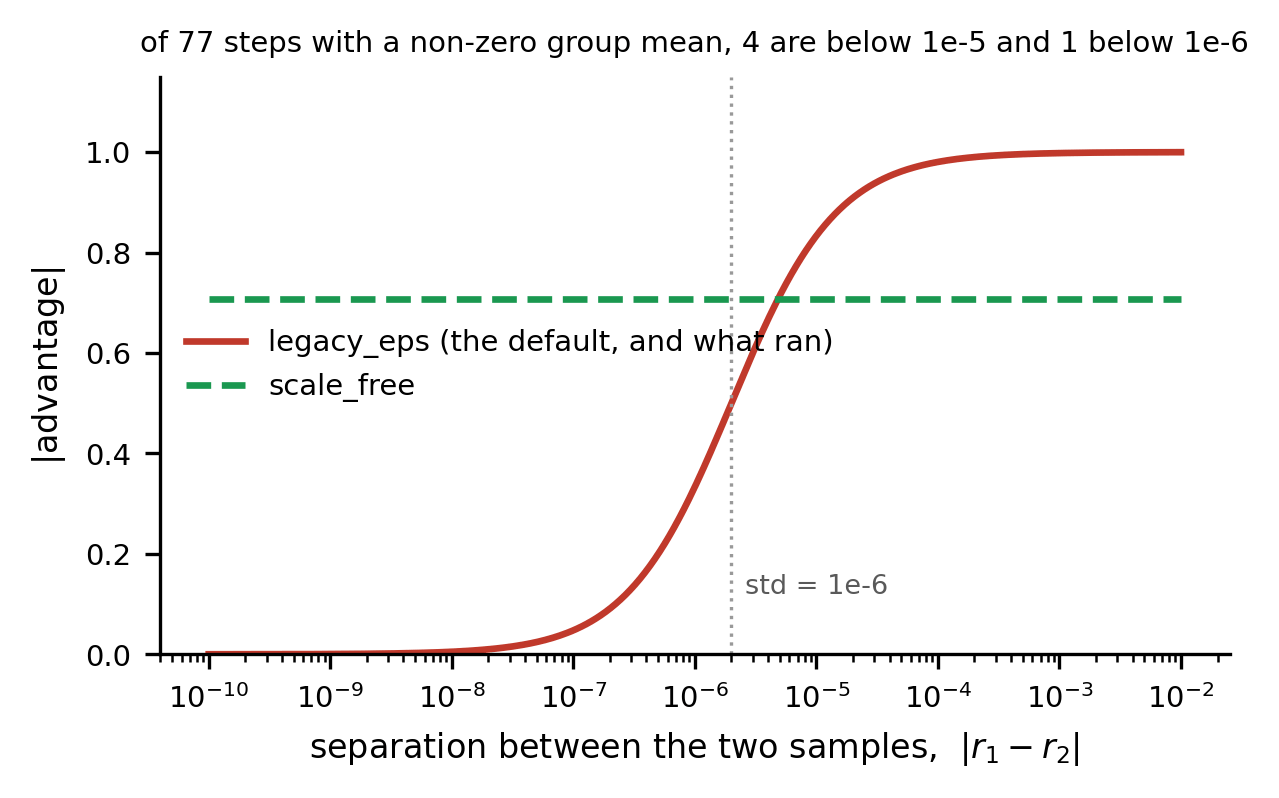

non-zero steps 77; mean<1e-5: 4; mean<1e-6: 1


In [6]:
# F3 -- what the advantage does at K=2 as the two samples separate. scale_free is
# flat everywhere: the size of the reward difference is simply not in the
# advantage, only its sign. legacy_eps is flat too once above its floor, and
# what it does below the floor is an artefact of the floor, not reward magnitude
# finding its way back in.
d = np.logspace(-10, -2, 400)          # |r1 - r2|
eps = SRC["advantage_std_eps"]
legacy = (d / 2) / (d / 2 + eps)                    # population std = d/2
scale_free = np.full_like(d, 1 / math.sqrt(2))      # unbiased std = d/sqrt(2)
fig, ax = plt.subplots(figsize=(4.6, 2.5))
ax.semilogx(d, legacy, lw=1.6, color="#c0392b", label="legacy_eps (the default, and what ran)")
ax.semilogx(d, scale_free, lw=1.6, color="#1a9850", ls="--", label="scale_free")
ax.axvline(2 * eps, color="0.6", lw=0.8, ls=":")
ax.text(2 * eps * 1.3, 0.12, "std = 1e-6", fontsize=6.5, color="0.35")
ax.set_xlabel(r"separation between the two samples,  $|r_1 - r_2|$")
ax.set_ylabel(r"$|$advantage$|$")
ax.set_ylim(0, 1.15); ax.legend(frameon=False, loc="center left")
tot = sum(RUNS[k]["n_nonzero"] for k in ORDER)
b5 = sum(RUNS[k]["n_mean_below_1e5"] for k in ORDER)
b6 = sum(RUNS[k]["n_mean_below_1e6"] for k in ORDER)
ax.set_title(f"of {tot} steps with a non-zero group mean, {b5} are below 1e-5 "
             f"and {b6} below 1e-6", fontsize=7, pad=6)
save(fig, "f3_k2_advantage")
print(f"non-zero steps {tot}; mean<1e-5: {b5}; mean<1e-6: {b6}")

## 4. What the group size buys, and what it does not

The measured fraction of zero-variance groups against group size comes from
PR #5 on this same line, carried here with its unequal step counts attached: the
two readings of 0.00 rest on 24 and 15 steps, not on equal power.

Raising K is the only change that addresses all three ways a group can carry no
gradient at once. Switching the std mode addresses one of them, costs nothing,
and should be done as well, but on its own it leaves the magnitude blindness
exactly where it was.

f4_group_size: 31 KiB


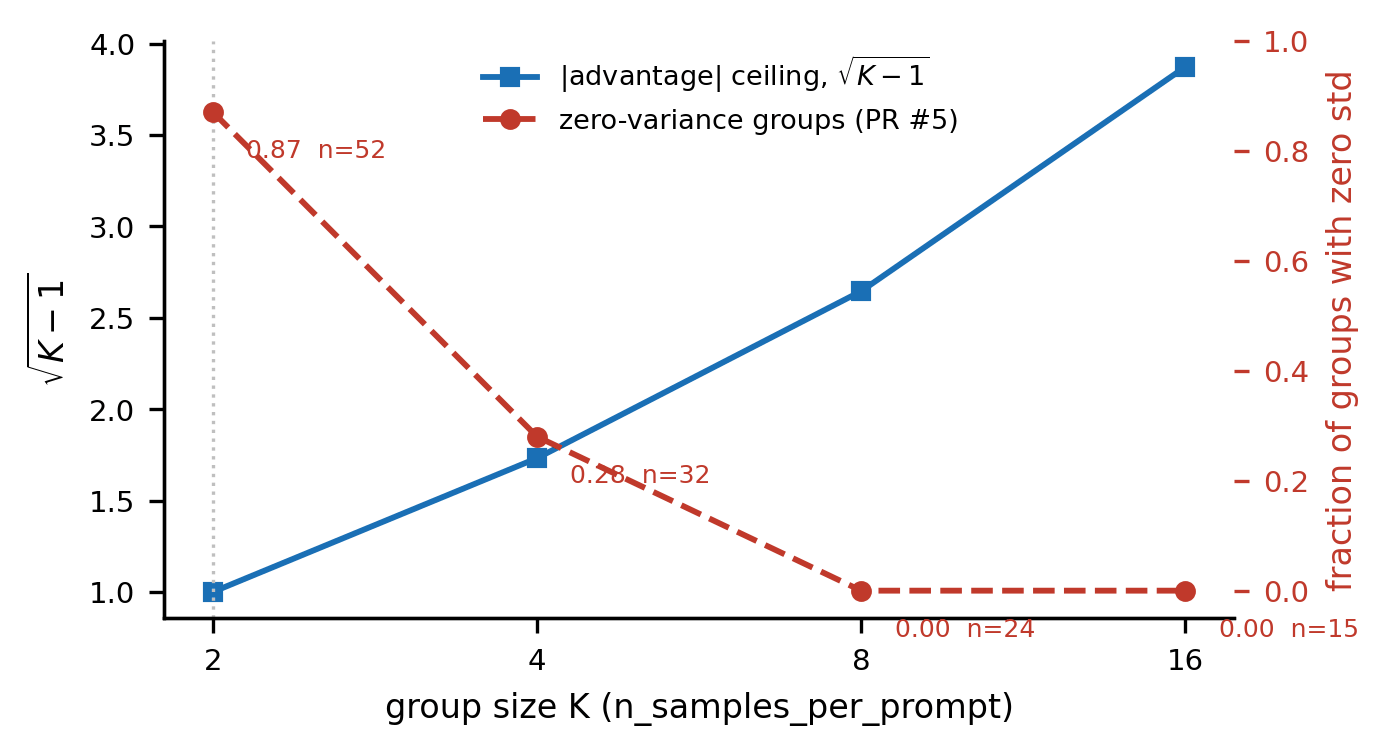

In [7]:
# F4 -- the ceiling scale_free proves, sqrt(K-1), against the measured fraction
# of zero-variance groups from PR #5. At K=2 the ceiling is 1 and the fraction
# is 0.87: the group size, not the normalisation, is what is binding.
z = F["zero_variance_vs_n_from_pr5"]
ks = sorted(int(k) for k in z["fraction_of_groups_with_zero_std"])
frac = [z["fraction_of_groups_with_zero_std"][str(k)] for k in ks]
steps = [z["step_counts"][str(k)] for k in ks]
fig, ax = plt.subplots(figsize=(4.6, 2.5))
ax.plot(ks, [math.sqrt(k - 1) for k in ks], "s-", ms=4, lw=1.4, color="#1a6fb5",
        label=r"$|$advantage$|$ ceiling, $\sqrt{K-1}$")
ax.set_xscale("log", base=2); ax.set_xticks(ks); ax.set_xticklabels(ks)
ax.set_xlabel("group size K (n_samples_per_prompt)"); ax.set_ylabel(r"$\sqrt{K-1}$")
ax2 = ax.twinx(); ax2.spines["top"].set_visible(False)
ax2.plot(ks, frac, "o--", ms=4, lw=1.4, color="#c0392b",
         label="zero-variance groups (PR #5)")
ax2.set_ylabel("fraction of groups with zero std", color="#c0392b")
ax2.tick_params(axis="y", colors="#c0392b"); ax2.set_ylim(-0.05, 1.0)
for k, f_, n in zip(ks, frac, steps):
    ax2.annotate(f"{f_:.2f}  n={n}", (k, f_), textcoords="offset points",
                 xytext=(8, -11), fontsize=6, color="#c0392b")
ax.axvline(2, color="0.75", lw=0.8, ls=":")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, loc="upper center", fontsize=6.5,
          bbox_to_anchor=(0.52, 1.02))
save(fig, "f4_group_size")

## 5. The K=8 cell, measured

`k8sft` ran the same SFT arm for the same 50 rollouts as `9b-sft-a`, so the group
counts compare with no adjustment for length: **49 of 100 groups carried no
gradient at K=2, and 9 of 100 at K=8.** Rollouts whose entire group mean was zero
went from 14 of 50 to 1 of 50.

Two limits on how far that reads. The cell also moved `UPDATES_PER_ROLLOUT` from
1 to 2, so it differs in two ways rather than one; the zero-variance column is
nevertheless a one-factor comparison, because those counters are computed over a
rollout's samples before any optimizer update and `UPDATES_PER_ROLLOUT` only sets
how many inner updates a rollout then gets. Every other quantity here is
confounded and should not be read as a K effect.

And 9 is not 0, which is what the ratchet predicts: a group scores above zero
only by beating the running best, so "all K samples failed to beat it" stays
possible at any K and merely becomes rare. Within this run the zeros are 3 of 50
in the first half against 6 of 50 in the second — the same direction as the
ratchet, on 9 events, which is not enough to establish it.

The epsilon floor never engaged: `count_lt_eps` equals `count_0.0` at every point
in both runs, so no group was ever attenuated rather than genuinely zero. On this
evidence `scale_free` would have bought nothing here — it remains the right
default, and it is not what these runs needed.

f6_k8_vs_k2: 64 KiB


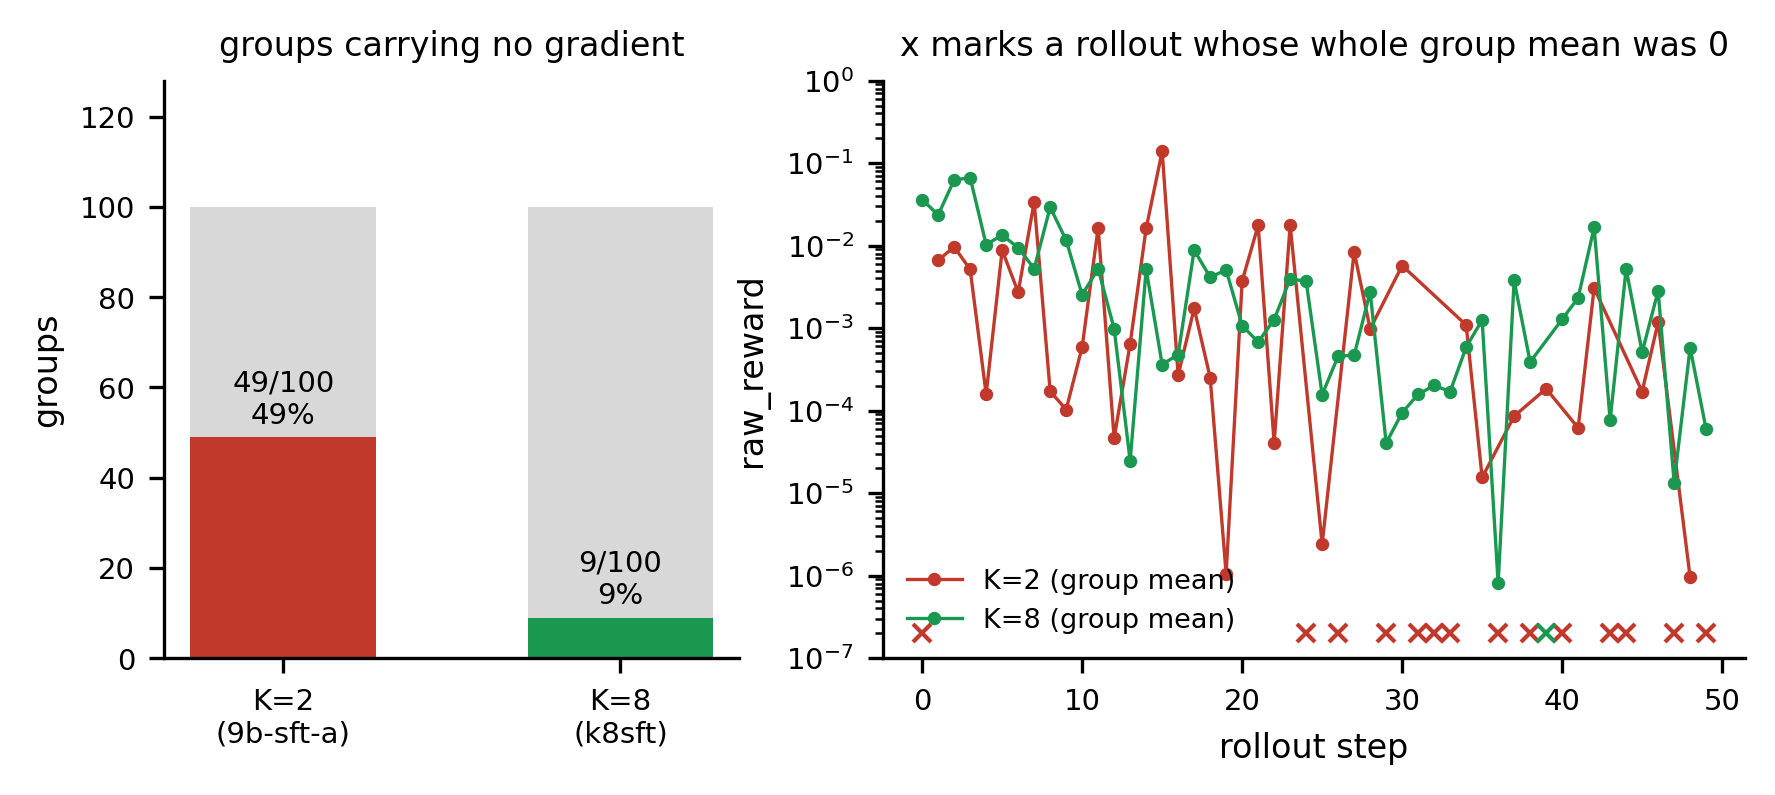

K=2 49/100 -> K=8 9/100


In [8]:
# F -- the K=8 cell against the K=2 run it matches exactly: same SFT arm, same 50
# rollouts, same 100 groups, so the counts compare with no adjustment. Only the
# zero-variance column is a one-factor comparison; see the caption.
K8, K2 = "k8sft", "9b-sft-a"
fig, (axL, axR) = plt.subplots(1, 2, figsize=(6.8, 2.5),
                               gridspec_kw={"width_ratios": [1, 1.5]})
labs = ["K=2\n(9b-sft-a)", "K=8\n(k8sft)"]
vals = [RUNS[K2]["groups_no_gradient"], RUNS[K8]["groups_no_gradient"]]
axL.bar(labs, [RUNS[K2]["groups_total"], RUNS[K8]["groups_total"]], 0.55, color="#d8d8d8")
axL.bar(labs, vals, 0.55, color=["#c0392b", "#1a9850"])
for i, v in enumerate(vals):
    axL.text(i, v + 3, f"{v}/100\n{v/100:.0%}", ha="center", fontsize=7)
axL.set_ylabel("groups"); axL.set_ylim(0, 128)
axL.set_title("groups carrying no gradient", fontsize=8)

for k, c, lab in ((K2, "#c0392b", "K=2"), (K8, "#1a9850", "K=8")):
    r = np.array(RUNS[k]["raw_reward"]); x = np.arange(len(r))
    nz = r > 0
    axR.semilogy(x[nz], r[nz], "o-", ms=2.2, lw=0.8, color=c, label=f"{lab} (group mean)")
    axR.plot(x[~nz], np.full((~nz).sum(), 2e-7), "x", ms=4.5, color=c)
axR.set_ylim(1e-7, 1); axR.set_xlabel("rollout step")
axR.set_ylabel("raw_reward"); axR.legend(frameon=False, fontsize=6.5, loc="lower left")
axR.set_title("x marks a rollout whose whole group mean was 0", fontsize=8)
save(fig, "f6_k8_vs_k2")
print(f"K=2 {RUNS[K2]['groups_no_gradient']}/100 -> K=8 {RUNS[K8]['groups_no_gradient']}/100")

## 6. What to change

Two of these are one line each. The third is the one that makes the next
diagnosis possible instead of guessing again.

1. **`n_samples_per_prompt` from 2 to 8.** Costs four times the rollouts per
   step. This is the only item that restores magnitude to the advantage.
2. **`--grpo-advantage-std-mode scale_free`.** Free. Removes the epsilon floor.
   `arguments.py` keeps the default on the defective branch deliberately so that
   flipping it does not split in-flight comparisons, so it has to be opted into
   per run and recorded.
3. **Log `components["kind"]`.** A zero in the log still cannot be attributed to
   a parse failure rather than to a round that found nothing better; `kind`
   separates them, is computed on every call, and appears in none of these logs.
   `zero_std/*` needs nothing — it is already there, in `runs/<RUN>/train.log`
   rather than in the orchestration log, and reading it is what turned the
   group-mean bound above into a measurement.

Not proposed here, but worth settling before tuning anything: the per-objective
clip at zero, and whether `reward_failure` and `reward_invalid` should stay
equal.

## 7. The numbers

`T2` is the citation list: every fact the text above asserts about the code,
with the file and line it was read from.

In [9]:
# The numbers behind the figures, for checking rather than for reading.
import pandas as pd
t1 = pd.DataFrame([{
    "run": k, "steps": RUNS[k]["steps"], "all-zero groups": RUNS[k]["n_zero"],
    "zero frac": f"{RUNS[k]['zero_frac']:.0%}",
    "first half": f"{RUNS[k]['zero_frac_first_half']:.0%}",
    "second half": f"{RUNS[k]['zero_frac_second_half']:.0%}",
    "K": RUNS[k]["n_samples_per_prompt"],
    "std mode": RUNS[k]["grpo_advantage_std_mode"],
    "normalize_advantages": RUNS[k]["normalize_advantages"],
} for k in ORDER])
print("T1  the three runs\n"); print(t1.to_string(index=False)); print()

t2 = pd.DataFrame([
    {"fact": "REWARD_POLICIES", "value": ", ".join(SRC["reward_policies"]),
     "where": f"env.py:{SRC['reward_policies_line']}"},
    {"fact": "default policy", "value": SRC["reward_default"],
     "where": f"env.py:{SRC['reward_default_line']}"},
    {"fact": "reward_failure", "value": SRC["reward_failure_value"],
     "where": f"env.py:{SRC['reward_failure_line']}"},
    {"fact": "reward_invalid", "value": SRC["reward_invalid_value"],
     "where": f"env.py:{SRC['reward_invalid_line']}"},
    {"fact": "baseline is the running best", "value": "_componentwise_best(all observations)",
     "where": f"env.py:{SRC['baseline_line']}"},
    {"fact": "per-objective clip at 0", "value": "max(0.0, a - b)",
     "where": f"env.py:{SRC['improvement_clip_line']}"},
    {"fact": "ADVANTAGE_STD_EPS", "value": SRC["advantage_std_eps"],
     "where": f"ppo_utils.py:{SRC['advantage_std_eps_line']}"},
    {"fact": "std mode default", "value": SRC["std_mode_default"],
     "where": f"arguments.py:{SRC['std_mode_default_line']}"},
    {"fact": "normalize_advantages default", "value": SRC["normalize_advantages_default"],
     "where": f"arguments.py:{SRC['normalize_advantages_line']}"},
    {"fact": "logged rollout/* is a mean", "value": "val.float().mean().item()",
     "where": f"data.py:{SRC['logged_value_is_mean_line']}"},
])
print("T2  where each fact comes from\n"); print(t2.to_string(index=False)); print()

print("T3  which log carries what\n")
print(f"  {'run':10s} {'zero_std in orch log':>21s} {'in train.log':>13s} {'reward kind':>12s}")
for k in ORDER:
    r = RUNS[k]
    print(f"  {k:10s} {str(r['zero_std_keys_in_orch_log']):>21s} "
          f"{str(r['zero_std_keys_in_train_log']):>13s} {str(r['reward_kind_in_train_log']):>12s}")
print("\n  The counters live in runs/<RUN>/train.log. Reading only the top-level")
print("  orchestration log is what made an earlier version report them as absent.")

t4 = pd.DataFrame([{
    "run": k,
    "groups": RUNS[k]["groups_total"],
    "no gradient": RUNS[k]["groups_no_gradient"],
    "std < 1e-6": RUNS[k]["groups_lt_eps"],
    "every sample 0": RUNS[k]["groups_exactly_zero"],
    "frac": f"{RUNS[k]['no_gradient_frac']:.0%}",
} for k in ORDER])
print("\nT4  the direct per-group measurement\n"); print(t4.to_string(index=False))

T1  the three runs

     run  steps  all-zero groups zero frac first half second half K   std mode normalize_advantages
9b-sft-a     50               14       28%         8%         48% 2 legacy_eps                False
9b-sft-b     29               13       45%        57%         33% 2 legacy_eps                False
 9b-base     28                3       11%         0%         21% 2 legacy_eps                False

T2  where each fact comes from

                        fact                                              value             where
             REWARD_POLICIES improvement, raw, binary, acquisition, hypervolume         env.py:50
              default policy                                        improvement         env.py:67
              reward_failure                                                0.0         env.py:68
              reward_invalid                                                0.0         env.py:69
baseline is the running best              _componentwise_